<a href="https://colab.research.google.com/github/B-313/B-s-Codedex-Workbook/blob/main/Assignment_UCB_MLBio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setting up Libraries

In [ ]:
#Libraries and set up
import numpy as np
import matplotlib.pyplot as plt

Class and Agents

In [ ]:
class Bandit:
    def __init__(self, k):
        self.k = k
        self.qtrue = np.random.normal(0, 1, k)
        self.bestaction = np.argmax(self.qtrue)

    def step(self, action):
        reward = np.random.normal(self.qtrue[action], 1)
        return reward

class Agent:
    def __init__(self, k, useucb=True, c=2):
        self.k = k
        self.useucb = useucb
        self.c = c
        self.reset()

    def reset(self):
        self.qestimates = np.zeros(self.k)
        self.actioncounts = np.zeros(self.k)
        self.totalsteps = 0

    def act(self):
        if self.useucb:
            ucbvalues = self.qestimates + self.c * np.sqrt(np.log(self.totalsteps + 1) / (self.actioncounts + 1e-5))
            return np.argmax(ucbvalues)
        return np.argmax(self.qestimates)  # Fallback (unused)

    def learn(self, action, reward):
        self.actioncounts[action] += 1
        self.qestimates[action] += (reward - self.qestimates[action]) / self.actioncounts[action]
        self.totalsteps += 1

Simulate 2000 Plays

In [ ]:
def simulate_ucb(k, runs=2000, steps=1000):
    avgrewards = np.zeros(steps)
    optimalactionperc = np.zeros(steps)

    for run in range(runs):
        bandit = Bandit(k)
        agent = Agent(k, useucb=True, c=2)
        agent.reset()

        for step in range(steps):
            action = agent.act()
            reward = bandit.step(action)
            agent.learn(action, reward)
            avgrewards[step] += reward
            if action == bandit.bestaction:
                optimalactionperc[step] += 1

    avgrewards /= runs
    optimalactionperc /= runs * 100  # %
    return {'UCB': avgrewards}, {'UCB': optimalactionperc}

Plot Results

In [ ]:
def plot_ucb(avgrewards, optimalactionperc, k):
    fig, axs = plt.subplots(2, 1, figsize=(12, 12))
    axs[0].plot(avgrewards['UCB'], label='UCB')
    axs[0].set_title(f'{k}-Armed Bandit Average Reward (UCB)')
    axs[0].set_xlabel('Steps')
    axs[0].set_ylabel('Average Reward')
    axs[0].legend()
    axs[0].grid(True)

    axs[1].plot(optimalactionperc['UCB'], label='UCB')
    axs[1].set_title(f'{k}-Armed Bandit Optimal Action (UCB)')
    axs[1].set_xlabel('Steps')
    axs[1].set_ylabel('% Optimal Action')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

Test

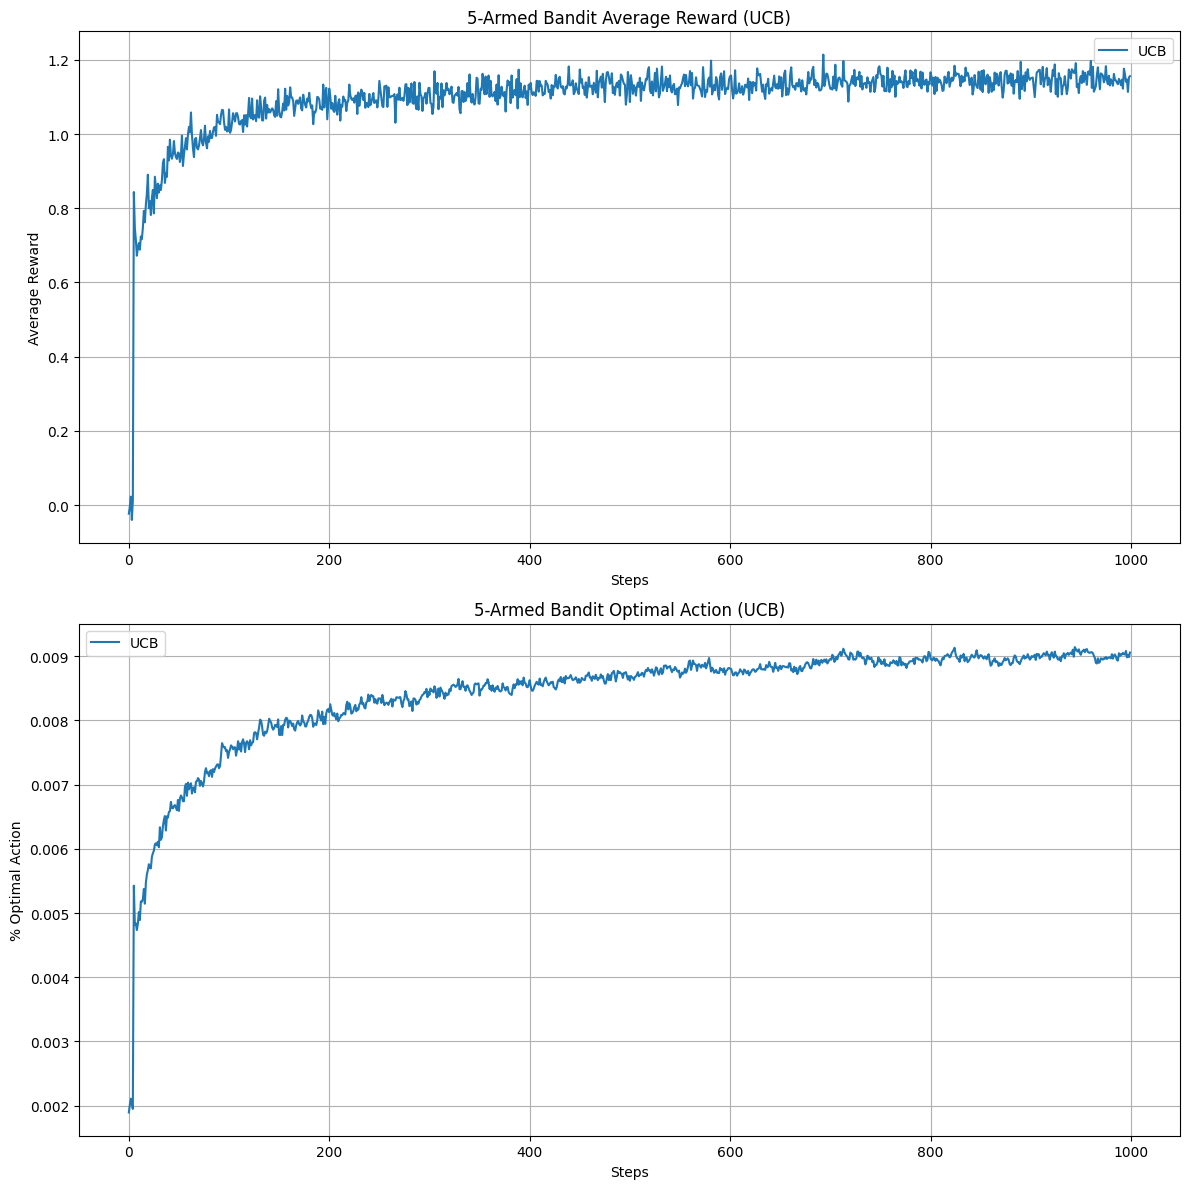

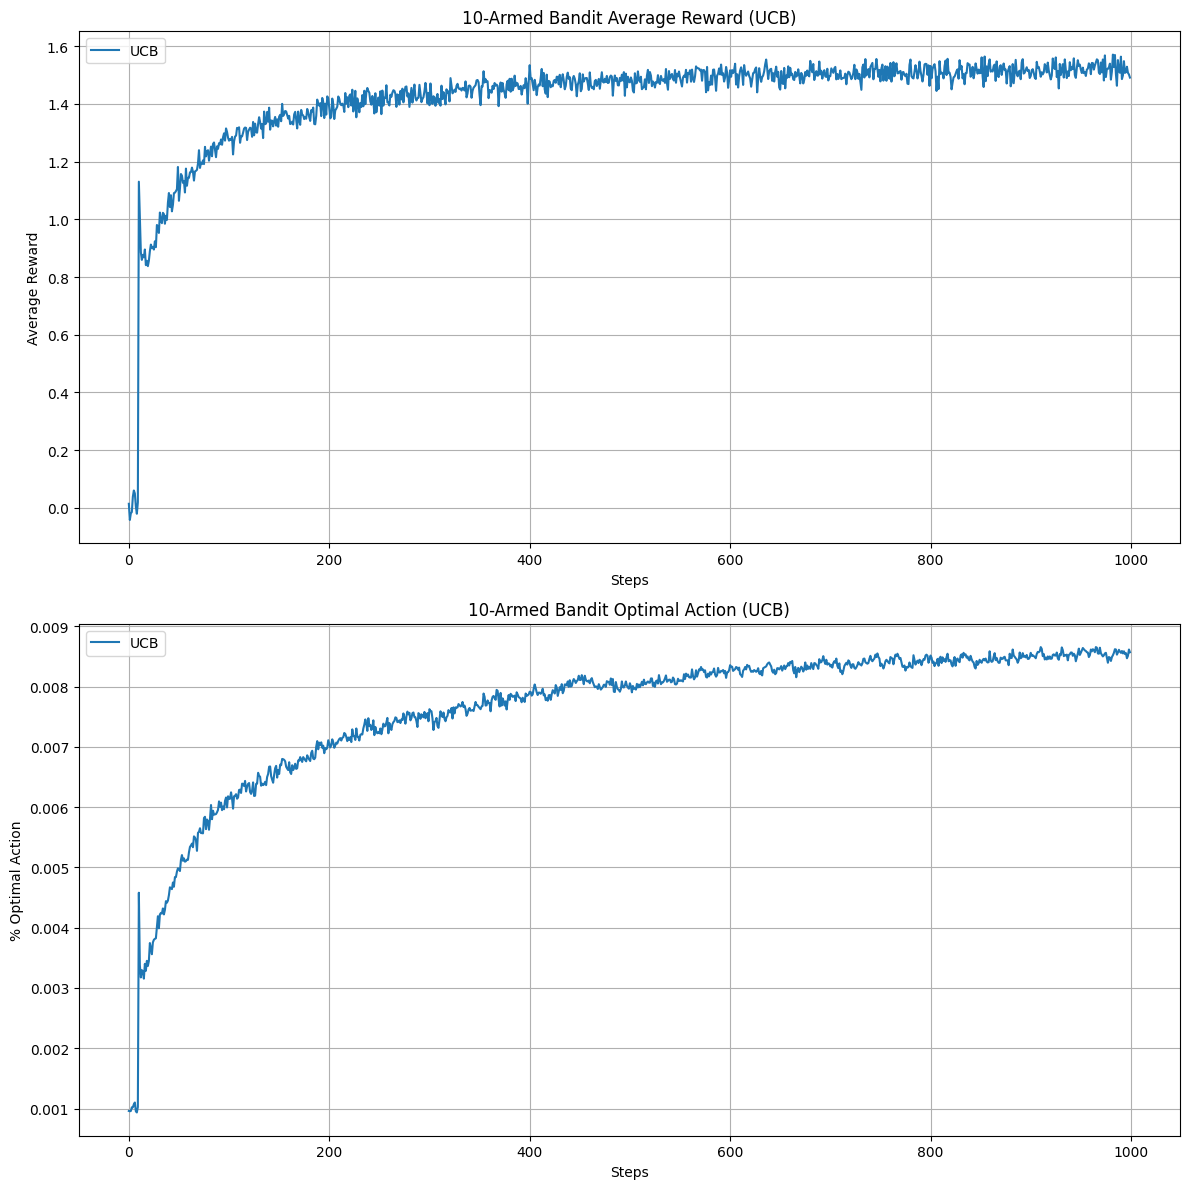

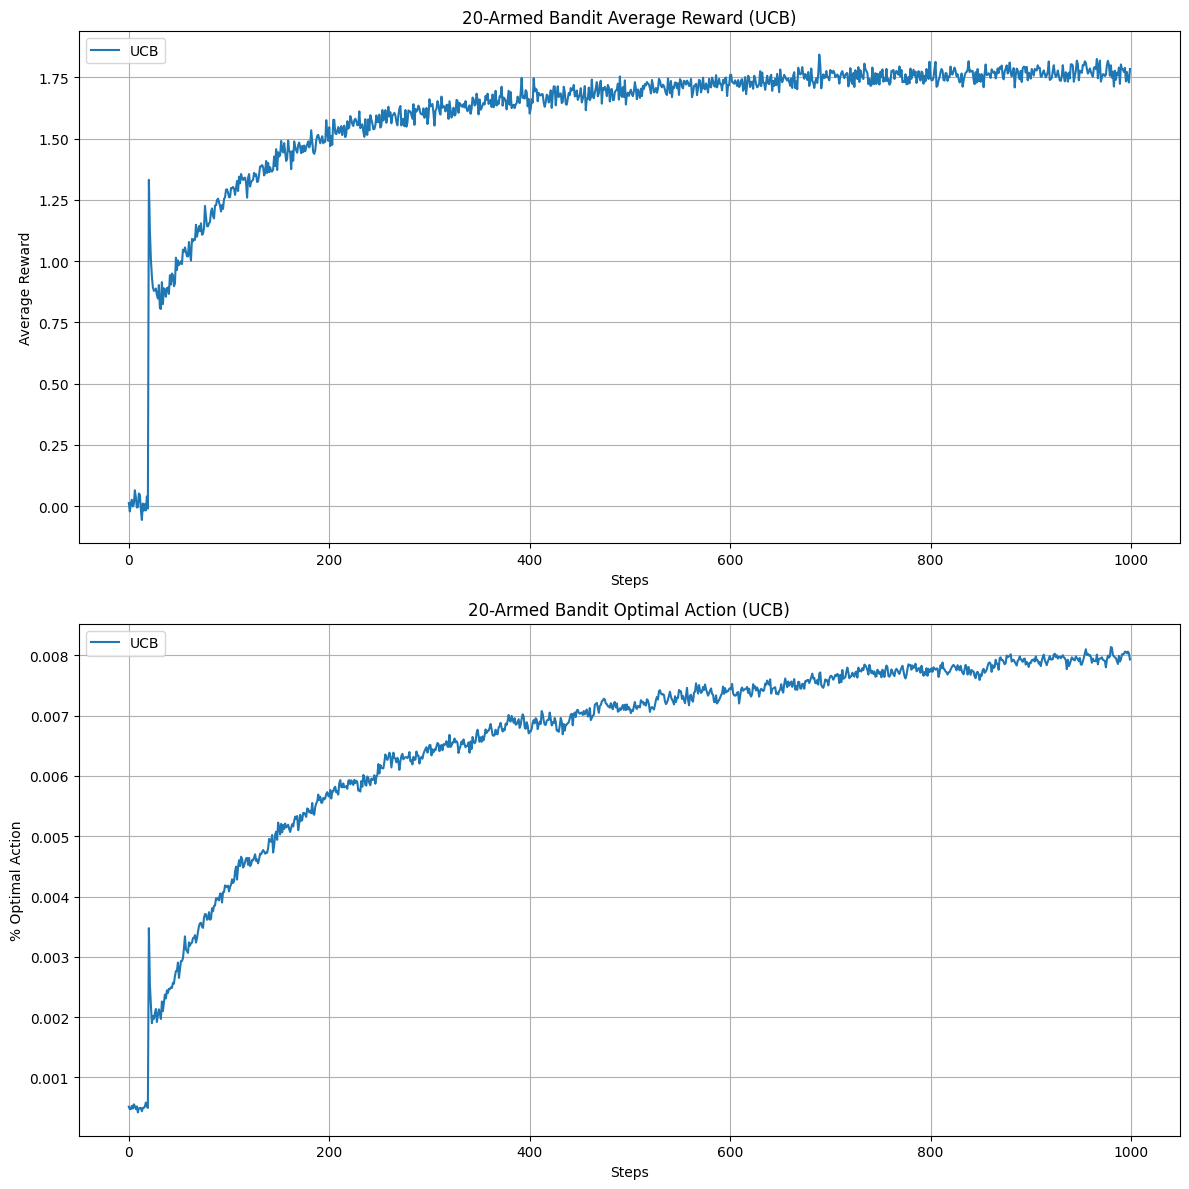

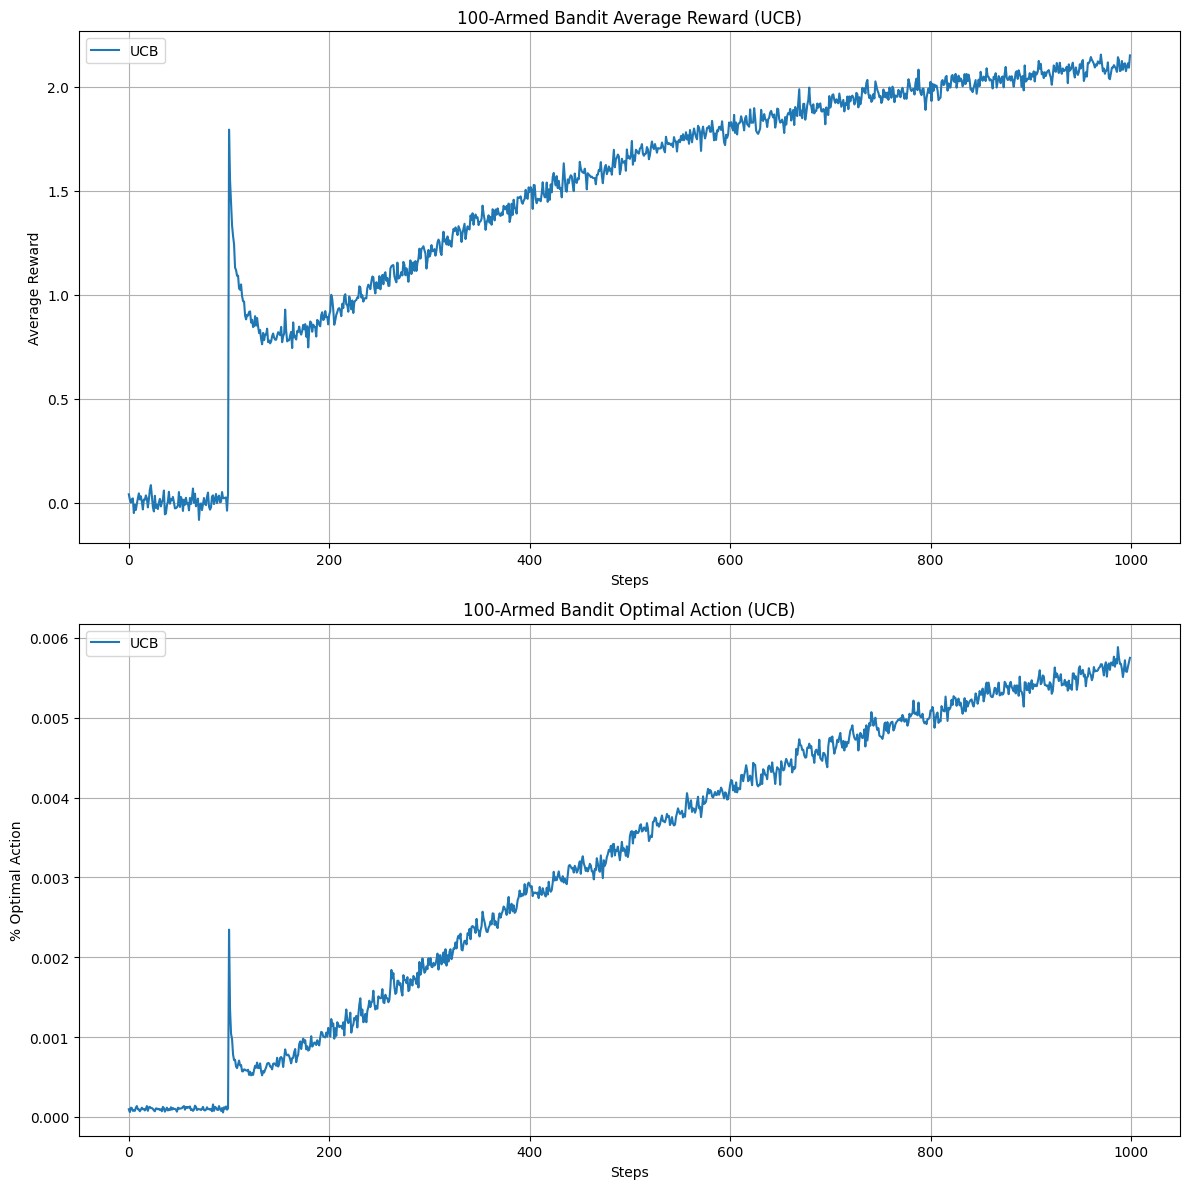

In [ ]:
ks = [5, 10, 20, 100]
for k in ks:
    avgrewards, optimalactionperc = simulate_ucb(k)
    plot_ucb(avgrewards, optimalactionperc, k)